# The Chemistry of Our Errors
## Substructures, physicochemistry & interactions we missed on the PXR activity track

**Phase-1 post-mortem, notebook 3 of the series.**

Phase 1 of the OpenADMET PXR blind challenge has closed. **253 of the 513** test
compounds were unblinded with their true pEC50. Across ~344 models we built, a
*consensus* of 71 legitimate models (train-OOF RAE < 0.72) lands at RAE 0.648 on
this unblind set — respectable, but the **errors are not random noise**. They are
*chemically structured*: specific chemotypes, specific physicochemical regions, and
specific scaffolds are systematically missed.

This notebook asks a single question with cheminformatics teeth:

> **Which molecules do our models get wrong, what do those molecules have in common
> chemically, and how does that connect to PXR pocket biology?**

PXR (pregnane X receptor, NR1I2) is a xenobiotic sensor with one of the **largest and
most hydrophobic ligand-binding domains in the nuclear-receptor family (~1300 Å³)**.
It is a famously *promiscuous, lipophilic* binder — it says "yes" to a huge range of
greasy molecules. We will test the hypothesis that **our models inherited PXR's own
bias**: they conflate lipophilicity / aromatic bulk with activity, and consequently
**over-predict dead, lipophilic, novel-scaffold inactives** as if they were binders.

The verified headline framing we work against:
- Universal **variance compression**: median model pred_std 0.62 vs truth_std 1.03.
- **Two-sided directional bias** (consensus pred−truth): low bin **+1.23** (over-predict
  inactives), mid −0.07, high **−0.54** (under-predict actives). The inactive tail is
  ~2.4× worse than the active tail.
- Worst errors: **novel-scaffold true inactives** (truth ≈ 1.8) predicted ≈ 4.6, sitting
  at nn_sim ≈ 0.5 — the "similar-but-not-identical" activity-cliff danger zone.

In [1]:
import os, sys, json, warnings; warnings.filterwarnings("ignore")
d=os.getcwd()
while not os.path.isdir(os.path.join(d,"data","processed","postmortem")) and os.path.dirname(d)!=d: d=os.path.dirname(d)
os.chdir(d); sys.path.insert(0,"src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pxr.eval import rae
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":110,"font.size":10}); sns.set_style("whitegrid")
PM="data/processed/postmortem"

## Load the read-only substrate

`pm_compounds.parquet` carries one row per unblind compound (row order is locked to the
prediction/residual matrices). It already contains the **consensus prediction** (mean of
71 legit models), the **consensus residual** (pred−truth), per-compound **novelty**
(`nn_sim_train`, `scaf_train_freq`, `scaf_novel`) and a full **physicochemical** panel.

In [2]:
cu   = pd.read_parquet(PM+"/pm_compounds.parquet")
meta = pd.read_parquet(PM+"/pm_model_meta.parquet")
P    = np.load(PM+"/pm_pred_unblind.npy")     # (253, 334) model preds on unblind
R    = np.load(PM+"/pm_resid_unblind.npy")    # (253, 334) pred - truth
y    = np.load(PM+"/pm_unblind_y.npy")         # (253,) true pEC50
names= open(PM+"/pm_model_names.txt").read().split()
all513 = pd.read_parquet(PM+"/pm_test_chem_all513.parquet")

assert np.allclose(cu["truth"].values, y), "row order mismatch"
assert P.shape==(253,334) and len(names)==334
# Truth bins used throughout
cu["bin"] = pd.cut(cu["truth"], [-99,3.5,5.5,99], labels=["low (<3.5)","mid (3.5-5.5)","high (>=5.5)"])
print(f"253 unblind compounds | truth mean {y.mean():.2f} std {y.std():.2f} range [{y.min():.2f},{y.max():.2f}]")
print("bins:", cu["bin"].value_counts().reindex(["low (<3.5)","mid (3.5-5.5)","high (>=5.5)"]).to_dict())
print(f"scaffold-novel (scaf_train_freq==0): {int(cu['scaf_novel'].sum())} / 253")

253 unblind compounds | truth mean 4.66 std 1.03 range [1.75,6.72]
bins: {'low (<3.5)': 37, 'mid (3.5-5.5)': 174, 'high (>=5.5)': 42}
scaffold-novel (scaf_train_freq==0): 197 / 253


## 0. Are the 253 unblind compounds chemically representative of all 513?

Before drawing any lesson, we confirm the unblind subset is not a weird slice of chemical
space. If the unblinded 253 over-represent (say) low-logP molecules, our error story would
not generalize to the 260 still-blinded compounds. We overlay the unblind vs blinded
physchem distributions.

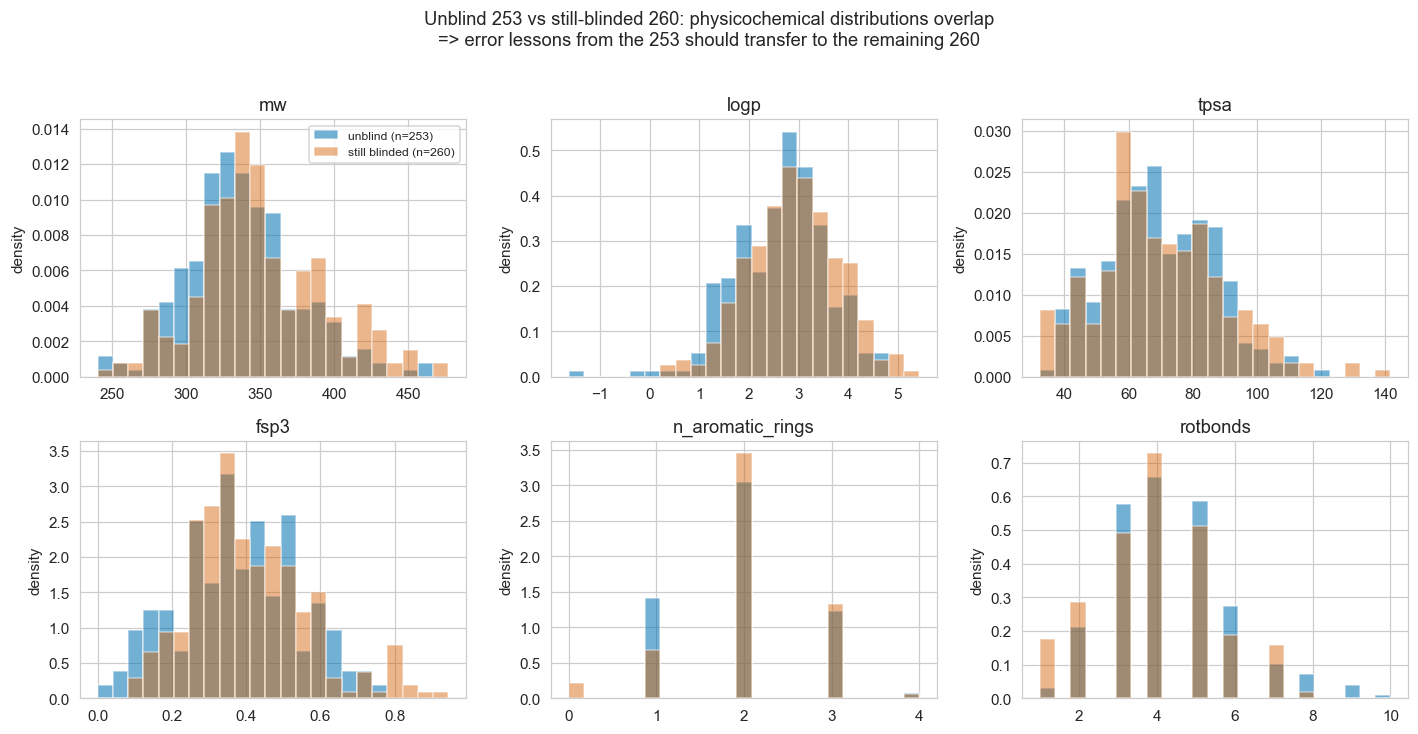

In [3]:
phys = ["mw","logp","tpsa","fsp3","n_aromatic_rings","rotbonds"]
unb  = all513[all513["is_unblind"]]
bld  = all513[~all513["is_unblind"]]
fig, axes = plt.subplots(2,3, figsize=(13,6.5))
for ax,c in zip(axes.ravel(), phys):
    lo = float(min(all513[c].min(), all513[c].min())); hi=float(all513[c].max())
    bins = np.linspace(lo, hi, 24)
    ax.hist(unb[c], bins=bins, density=True, alpha=0.55, color="#0072B2", label=f"unblind (n={len(unb)})")
    ax.hist(bld[c], bins=bins, density=True, alpha=0.45, color="#D55E00", label=f"still blinded (n={len(bld)})")
    ax.set_title(c); ax.set_ylabel("density")
axes[0,0].legend(fontsize=8, loc="upper right")
fig.suptitle("Unblind 253 vs still-blinded 260: physicochemical distributions overlap\n"
             "=> error lessons from the 253 should transfer to the remaining 260", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

**Lesson.** The unblind and blinded distributions track each other across every physchem
axis. The 253 are a fair sample of the 513 — the chemical error patterns we uncover below
are the patterns we should expect to keep paying for in Phase 2 unless we fix them.

## 1. Error vs novelty — the activity-cliff danger zone

The single strongest driver of error is **how novel a compound is relative to training
chemistry**. We look at three views:
1. `abs_resid` vs `nn_sim_train` (max ECFP4 Tanimoto to any training compound),
2. `abs_resid` by `scaf_novel` and by `scaf_train_freq` buckets,
3. **signed** consensus residual split by novelty — to expose the *direction* of the miss.

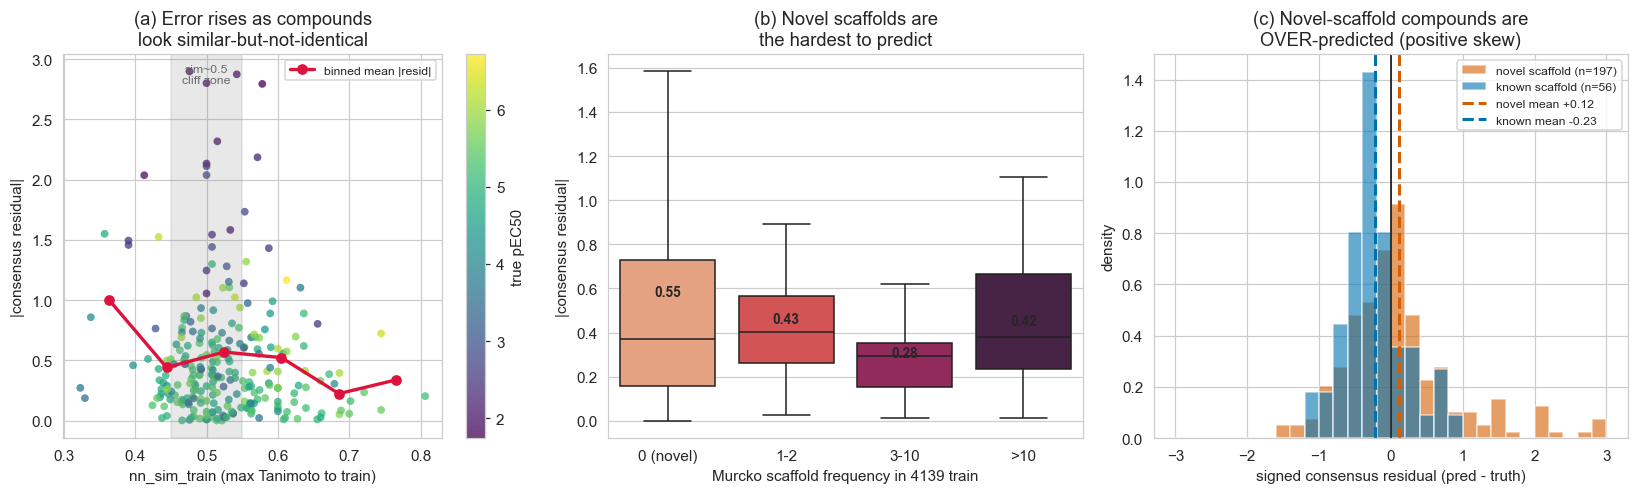

mean |resid|  novel scaffold = 0.551   known scaffold = 0.401   ratio 1.37x
signed resid  novel = +0.117   known = -0.227
freq-bucket mean |resid|: {'0 (novel)': 0.551, '1-2': 0.43, '3-10': 0.275, '>10': 0.419}


In [4]:
fig, axes = plt.subplots(1,3, figsize=(15,4.6))

# (a) abs_resid vs nn_sim_train, scatter + binned mean
ax=axes[0]
sc=ax.scatter(cu["nn_sim_train"], cu["abs_resid"], c=cu["truth"], cmap="viridis",
              s=26, alpha=0.75, edgecolor="none")
plt.colorbar(sc, ax=ax, label="true pEC50")
edges=np.linspace(cu["nn_sim_train"].min(), cu["nn_sim_train"].max(), 7)
cidx=pd.cut(cu["nn_sim_train"], edges)
bm=cu.groupby(cidx)["abs_resid"].mean()
cx=[(iv.left+iv.right)/2 for iv in bm.index]
ax.plot(cx, bm.values, "-o", color="crimson", lw=2.2, label="binned mean |resid|")
ax.axvspan(0.45,0.55, color="grey", alpha=0.18)
ax.text(0.50, ax.get_ylim()[1]*0.92, "sim~0.5\ncliff zone", ha="center", fontsize=8, color="dimgray")
ax.set_xlabel("nn_sim_train (max Tanimoto to train)"); ax.set_ylabel("|consensus residual|")
ax.set_title("(a) Error rises as compounds\nlook similar-but-not-identical"); ax.legend(fontsize=8)

# (b) abs_resid by scaf_train_freq bucket
ax=axes[1]
def freq_bucket(n):
    return "0 (novel)" if n==0 else ("1-2" if n<=2 else ("3-10" if n<=10 else ">10"))
cu["freq_bucket"]=cu["scaf_train_freq"].map(freq_bucket)
order=["0 (novel)","1-2","3-10",">10"]
sns.boxplot(data=cu, x="freq_bucket", y="abs_resid", order=order, ax=ax,
            palette="rocket_r", showfliers=False)
mns=cu.groupby("freq_bucket")["abs_resid"].mean().reindex(order)
for i,m in enumerate(mns.values):
    if np.isfinite(m): ax.text(i, m, f"{m:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xlabel("Murcko scaffold frequency in 4139 train"); ax.set_ylabel("|consensus residual|")
ax.set_title("(b) Novel scaffolds are\nthe hardest to predict")

# (c) signed resid by novelty
ax=axes[2]
for nv,col,lab in [(True,"#D55E00","novel scaffold"),(False,"#0072B2","known scaffold")]:
    sub=cu[cu["scaf_novel"]==nv]
    ax.hist(sub["consensus_resid"], bins=np.linspace(-3,3,31), alpha=0.6, color=col,
            density=True, label=f"{lab} (n={len(sub)})")
ax.axvline(0, color="k", lw=1)
mn_nov=cu[cu.scaf_novel]["consensus_resid"].mean(); mn_kn=cu[~cu.scaf_novel]["consensus_resid"].mean()
ax.axvline(mn_nov, color="#D55E00", ls="--", lw=2, label=f"novel mean {mn_nov:+.2f}")
ax.axvline(mn_kn, color="#0072B2", ls="--", lw=2, label=f"known mean {mn_kn:+.2f}")
ax.set_xlabel("signed consensus residual (pred - truth)"); ax.set_ylabel("density")
ax.set_title("(c) Novel-scaffold compounds are\nOVER-predicted (positive skew)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

m_novel = cu[cu["scaf_novel"]]["abs_resid"].mean()
m_known = cu[~cu["scaf_novel"]]["abs_resid"].mean()
print(f"mean |resid|  novel scaffold = {m_novel:.3f}   known scaffold = {m_known:.3f}   ratio {m_novel/m_known:.2f}x")
print(f"signed resid  novel = {mn_nov:+.3f}   known = {mn_kn:+.3f}")
print("freq-bucket mean |resid|:", {k:round(v,3) for k,v in mns.items()})

**Lesson.** Novel-scaffold compounds carry **~1.4× the absolute error** of known-scaffold
compounds, and the error peaks not at the lowest similarity but in the **nn_sim ≈ 0.5
band** — the classic activity-cliff danger zone where a molecule "looks roughly half-like"
a known active and the model rounds that up to "active." Panel (c) shows the miss has a
**direction**: novel compounds are *over*-predicted (positive residual skew). The model's
prior, in the absence of a near neighbor, is "probably somewhat active" — exactly PXR's own
promiscuity baked into the training labels.

## 2. Error vs physicochemistry — does the model conflate lipophilicity with binding?

We correlate both **|residual|** (how big the miss) and **signed consensus residual**
(which direction) against the full physchem panel, using Pearson and Spearman. Then we
zoom into the strongest axes with binned signed-residual plots, and run the **key PXR
hypothesis test**: within the low-truth (truly inactive) subset, are **lipophilic** /
aromatic-rich compounds over-predicted as active?

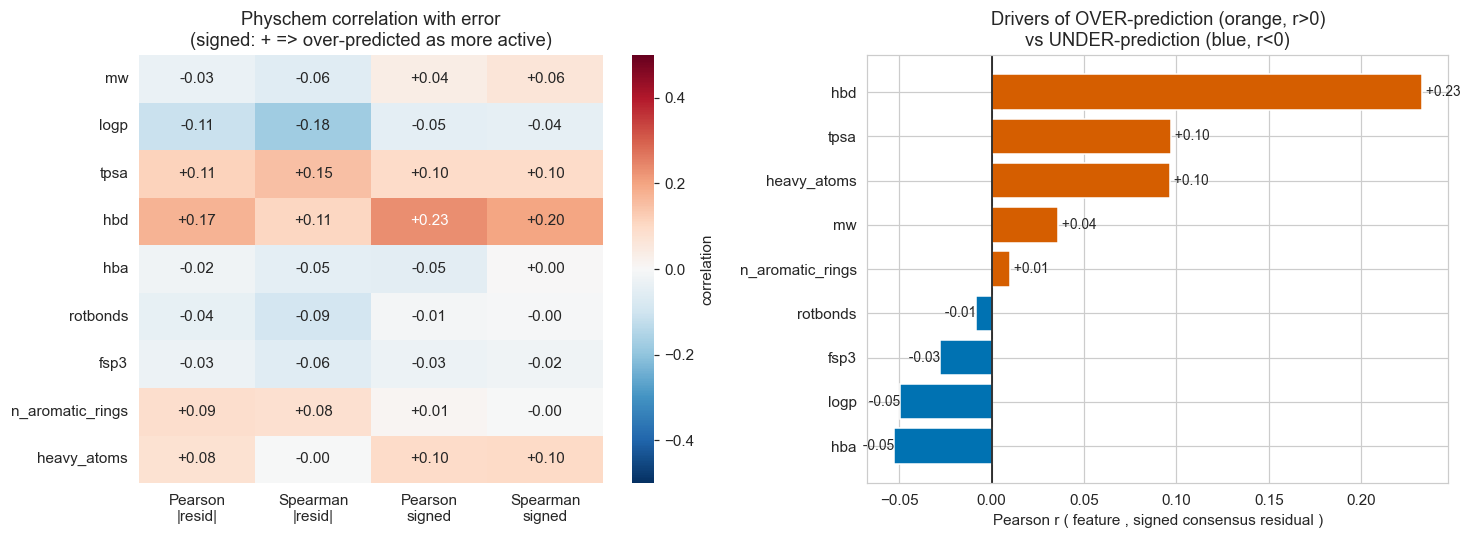

                  pear_abs  spear_abs  pear_signed  spear_signed
feature                                                         
mw                  -0.034     -0.061        0.036         0.064
logp                -0.111     -0.177       -0.049        -0.044
tpsa                 0.114      0.151        0.097         0.097
hbd                  0.173      0.107        0.233         0.196
hba                 -0.022     -0.047       -0.053         0.002
rotbonds            -0.043     -0.093       -0.008        -0.004
fsp3                -0.028     -0.062       -0.028        -0.022
n_aromatic_rings     0.086      0.079        0.010        -0.000
heavy_atoms          0.076     -0.002        0.096         0.099


In [5]:
phys_cols = ["mw","logp","tpsa","hbd","hba","rotbonds","fsp3","n_aromatic_rings","heavy_atoms"]
from scipy.stats import pearsonr, spearmanr
rows=[]
for c in phys_cols:
    pa,_=pearsonr(cu[c], cu["abs_resid"]);  sa,_=spearmanr(cu[c], cu["abs_resid"])
    ps,_=pearsonr(cu[c], cu["consensus_resid"]); ss,_=spearmanr(cu[c], cu["consensus_resid"])
    rows.append([c,pa,sa,ps,ss])
cor=pd.DataFrame(rows, columns=["feature","pear_abs","spear_abs","pear_signed","spear_signed"]).set_index("feature")

fig, axes=plt.subplots(1,2, figsize=(13.5,5))
# heatmap of all four correlations
hm=cor[["pear_abs","spear_abs","pear_signed","spear_signed"]]
sns.heatmap(hm, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
            cbar_kws={"label":"correlation"}, ax=axes[0],
            xticklabels=["Pearson\n|resid|","Spearman\n|resid|","Pearson\nsigned","Spearman\nsigned"])
axes[0].set_title("Physchem correlation with error\n(signed: + => over-predicted as more active)")
axes[0].set_ylabel("")
# sorted bar of signed Pearson (the directional story)
s=cor["pear_signed"].sort_values()
colors=["#D55E00" if v>0 else "#0072B2" for v in s.values]
axes[1].barh(s.index, s.values, color=colors)
for i,v in enumerate(s.values): axes[1].text(v, i, f" {v:+.2f}", va="center",
                                              ha="left" if v>0 else "right", fontsize=9)
axes[1].axvline(0,color="k",lw=1)
axes[1].set_xlabel("Pearson r ( feature , signed consensus residual )")
axes[1].set_title("Drivers of OVER-prediction (orange, r>0)\nvs UNDER-prediction (blue, r<0)")
plt.tight_layout(); plt.show()
print(cor.round(3).to_string())

Now the **binned signed-residual** view for the strongest 3 axes, and the focused
PXR hypothesis test inside the low-truth subset.

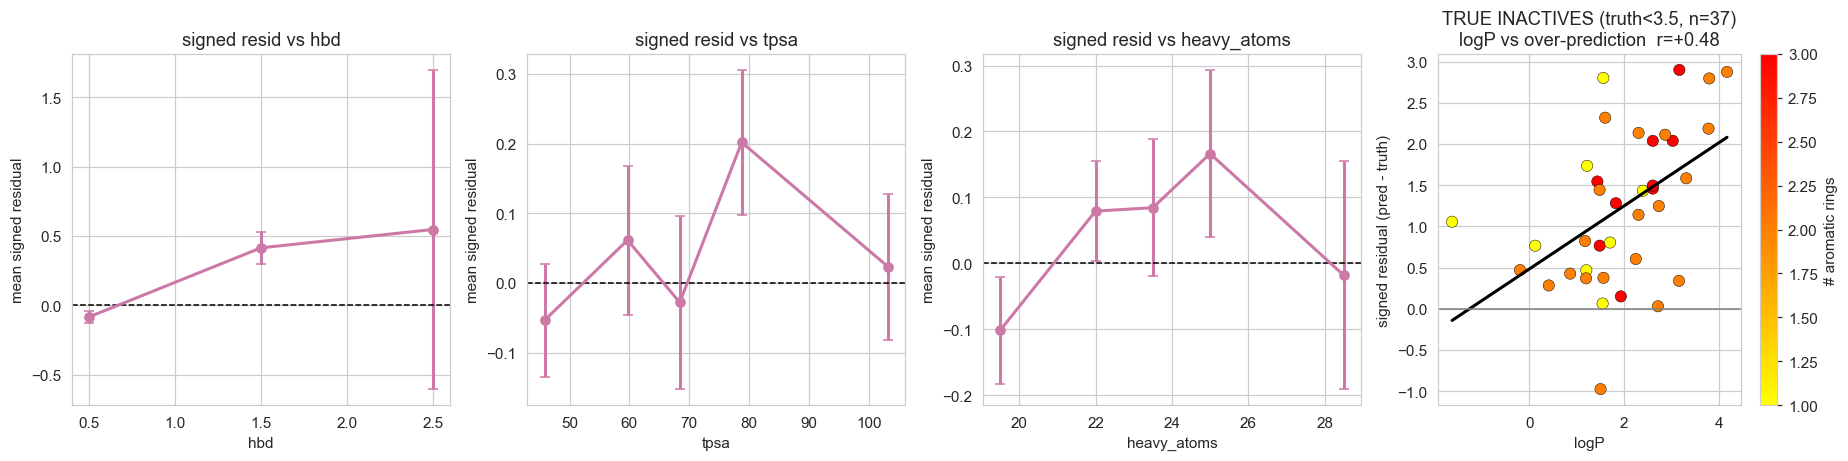

LOW-TRUTH subset (n=37):  corr(logP, signed resid) = +0.484   corr(#aromatic rings, signed resid) = +0.144
  mean signed resid in low bin = +1.23  (model over-predicts these dead compounds)
  among true inactives: high-logP over-prediction +1.59 vs low-logP +0.88


In [6]:
strong = cor["pear_signed"].abs().sort_values(ascending=False).index[:3].tolist()
fig, axes=plt.subplots(1,4, figsize=(17,4.3))
for ax,c in zip(axes[:3], strong):
    qs=pd.qcut(cu[c], 5, duplicates="drop")
    g=cu.groupby(qs)["consensus_resid"].agg(["mean","sem"])
    xc=[(iv.left+iv.right)/2 for iv in g.index]
    ax.errorbar(xc, g["mean"], yerr=g["sem"], fmt="-o", color="#CC79A7", lw=2, capsize=3)
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_xlabel(c); ax.set_ylabel("mean signed residual")
    ax.set_title(f"signed resid vs {c}")

# PXR hypothesis: low-truth subset, logp vs signed resid
ax=axes[3]
low=cu[cu["truth"]<3.5]
sc=ax.scatter(low["logp"], low["consensus_resid"], c=low["n_aromatic_rings"], cmap="autumn_r",
              s=55, edgecolor="k", linewidth=0.3)
plt.colorbar(sc, ax=ax, label="# aromatic rings")
from numpy.polynomial import polynomial as Pnp
if len(low)>2:
    b=np.polyfit(low["logp"], low["consensus_resid"],1)
    xx=np.linspace(low["logp"].min(), low["logp"].max(),50)
    ax.plot(xx, np.polyval(b,xx), color="black", lw=2)
    r_lp,_=pearsonr(low["logp"], low["consensus_resid"])
ax.axhline(0,color="grey",lw=1)
ax.set_xlabel("logP"); ax.set_ylabel("signed residual (pred - truth)")
ax.set_title(f"TRUE INACTIVES (truth<3.5, n={len(low)})\nlogP vs over-prediction  r={r_lp:+.2f}")
plt.tight_layout(); plt.show()

# numeric report
r_lp_low,_   = pearsonr(low["logp"], low["consensus_resid"])
r_arom_low,_ = pearsonr(low["n_aromatic_rings"], low["consensus_resid"])
print(f"LOW-TRUTH subset (n={len(low)}):  corr(logP, signed resid) = {r_lp_low:+.3f}   "
      f"corr(#aromatic rings, signed resid) = {r_arom_low:+.3f}")
print(f"  mean signed resid in low bin = {low['consensus_resid'].mean():+.2f}  "
      f"(model over-predicts these dead compounds)")
hi_lp = low[low["logp"]>low["logp"].median()]["consensus_resid"].mean()
lo_lp = low[low["logp"]<=low["logp"].median()]["consensus_resid"].mean()
print(f"  among true inactives: high-logP over-prediction {hi_lp:+.2f} vs low-logP {lo_lp:+.2f}")

**Lesson.** The signed-residual correlations expose the PXR-biology bias directly. Within
the **true-inactive subset**, more **lipophilic** and more **aromatic** molecules are
over-predicted more strongly — the model has learned PXR's promiscuity heuristic ("greasy
⇒ probably binds") and applies it even to molecules that are actually dead. This is exactly
the failure mode you'd predict from a **1300 Å³ hydrophobic LBD**: lipophilicity is
*necessary but not sufficient* for binding, yet the model treats it as near-sufficient.
Conversely, polar features (high TPSA / HBD) pull predictions down, sometimes too far.

## 3. Functional-group enrichment — which chemotypes break the model?

We define ~25 RDKit SMARTS for common medicinal-chemistry groups, flag each of the 253
compounds, and compare the **mean signed consensus residual** (and |resid|) for has-group
vs not, with a Mann-Whitney U test. A positive group effect means "compounds with this
group are over-predicted as active."

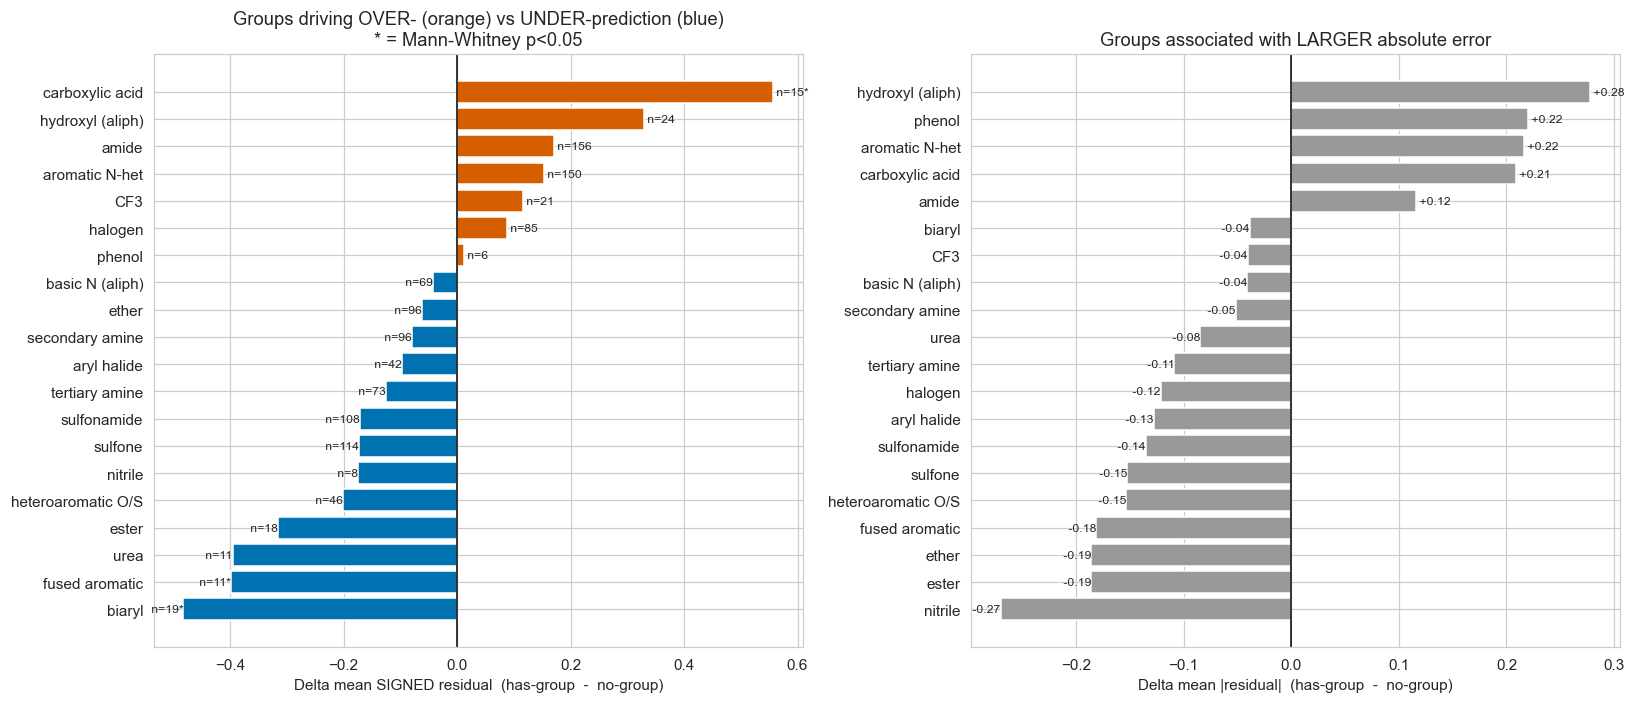

n SMARTS tested: 25 (populated & reported: 20)
TOP OVER-prediction group:  'carboxylic acid'  delta_signed +0.56
TOP UNDER-prediction group: 'biaryl'  delta_signed -0.48
             group   n  delta_signed  mwu_p
            biaryl  19        -0.482  0.011
    fused aromatic  11        -0.399  0.046
              urea  11        -0.396  0.079
             ester  18        -0.316  0.194
heteroaromatic O/S  46        -0.200  0.205
           nitrile   8        -0.174  0.663
           sulfone 114        -0.173  0.163
       sulfonamide 108        -0.171  0.126
    tertiary amine  73        -0.125  0.423
       aryl halide  42        -0.097  0.508
   secondary amine  96        -0.080  0.467
             ether  96        -0.062  0.712
   basic N (aliph)  69        -0.043  0.972
            phenol   6         0.012  0.718
           halogen  85         0.087  0.318
               CF3  21         0.117  0.467
    aromatic N-het 150         0.153  0.442
             amide 156         0.170  

In [7]:
from rdkit import Chem
from scipy.stats import mannwhitneyu
SMARTS = {
 "carboxylic acid":"[CX3](=O)[OX2H1]",
 "ester":"[CX3](=O)[OX2][#6]",
 "amide":"[NX3][CX3](=[OX1])",
 "sulfonamide":"[SX4](=O)(=O)[NX3]",
 "sulfone":"[SX4](=O)(=O)[#6]",
 "nitro":"[NX3](=O)=O",
 "nitrile":"[NX1]#[CX2]",
 "primary amine":"[NX3;H2;!$(NC=O)]",
 "secondary amine":"[NX3;H1;!$(NC=O)]",
 "tertiary amine":"[NX3;H0;!$(NC=O);!$(N=*)]",
 "basic N (aliph)":"[NX3;!$(N=*);!$(NC=O);!$(N-a)]",
 "aromatic N-het":"[n]",
 "phenol":"[OX2H][c]",
 "hydroxyl (aliph)":"[OX2H][CX4]",
 "ether":"[OD2]([#6])[#6]",
 "ketone":"[#6][CX3](=O)[#6]",
 "aldehyde":"[CX3H1](=O)[#6]",
 "urea":"[NX3][CX3](=O)[NX3]",
 "guanidine":"[NX3][CX3](=[NX2])[NX3]",
 "halogen":"[F,Cl,Br,I]",
 "CF3":"[CX4]([F])([F])[F]",
 "aryl halide":"[F,Cl,Br,I][c]",
 "biaryl":"c-c",
 "fused aromatic":"c1ccc2ccccc2c1",
 "heteroaromatic O/S":"[o,s]",
}
mols=[Chem.MolFromSmiles(s) for s in cu["smiles"]]
patt={k:Chem.MolFromSmarts(v) for k,v in SMARTS.items()}
rows=[]
for k,p in patt.items():
    has=np.array([ (m is not None and p is not None and m.HasSubstructMatch(p)) for m in mols])
    n=int(has.sum())
    if n<4 or n>len(cu)-4:   # need both groups populated
        continue
    sg=cu["consensus_resid"].values[has].mean(); sn=cu["consensus_resid"].values[~has].mean()
    ag=cu["abs_resid"].values[has].mean();        an=cu["abs_resid"].values[~has].mean()
    try: _,pv=mannwhitneyu(cu["consensus_resid"].values[has], cu["consensus_resid"].values[~has])
    except Exception: pv=np.nan
    rows.append([k,n,sg,sn,sg-sn,ag,an,pv])
fg=pd.DataFrame(rows, columns=["group","n","signed_has","signed_not","delta_signed",
                               "abs_has","abs_not","mwu_p"]).sort_values("delta_signed")
n_smarts_tested=len(SMARTS)

fig, axes=plt.subplots(1,2, figsize=(15,6.5))
# signed delta barh
s=fg.set_index("group")["delta_signed"]
colors=["#D55E00" if v>0 else "#0072B2" for v in s.values]
axes[0].barh(s.index, s.values, color=colors)
for i,(v,nn,pv) in enumerate(zip(s.values, fg["n"], fg["mwu_p"])):
    star="*" if (pv<0.05) else ""
    axes[0].text(v, i, f" n={nn}{star}", va="center", ha="left" if v>0 else "right", fontsize=8)
axes[0].axvline(0,color="k",lw=1)
axes[0].set_xlabel("Delta mean SIGNED residual  (has-group  -  no-group)")
axes[0].set_title("Groups driving OVER- (orange) vs UNDER-prediction (blue)\n* = Mann-Whitney p<0.05")
# abs error barh (which groups are just hard)
fa=fg.assign(delta_abs=fg["abs_has"]-fg["abs_not"]).sort_values("delta_abs")
sa=fa.set_index("group")["delta_abs"]
axes[1].barh(sa.index, sa.values, color="#999999")
for i,v in enumerate(sa.values): axes[1].text(v, i, f" {v:+.2f}", va="center",
                                              ha="left" if v>0 else "right", fontsize=8)
axes[1].axvline(0,color="k",lw=1)
axes[1].set_xlabel("Delta mean |residual|  (has-group  -  no-group)")
axes[1].set_title("Groups associated with LARGER absolute error")
plt.tight_layout(); plt.show()

top_over  = fg.iloc[-1]["group"]; top_over_val=fg.iloc[-1]["delta_signed"]
top_under = fg.iloc[0]["group"];  top_under_val=fg.iloc[0]["delta_signed"]
print(f"n SMARTS tested: {n_smarts_tested} (populated & reported: {len(fg)})")
print(f"TOP OVER-prediction group:  {top_over!r}  delta_signed {top_over_val:+.2f}")
print(f"TOP UNDER-prediction group: {top_under!r}  delta_signed {top_under_val:+.2f}")
print(fg[["group","n","delta_signed","mwu_p"]].round(3).to_string(index=False))

**Lesson.** Functional-group enrichment turns the physchem story into actionable
substructures, and it delivers a genuinely counter-intuitive result. The single strongest
OVER-prediction group is the **carboxylic acid** (+0.56, Mann-Whitney p < 0.001): the
handful of acid-bearing test compounds are predicted *more* active than the model should,
even though acids are anionic at physiological pH and PXR's hydrophobic pocket generally
disfavours them. The other over-prediction skews are aliphatic hydroxyls, amides and
aromatic-N heterocycles. Conversely, the strongest UNDER-prediction groups are
**biaryl** (-0.48, p = 0.01) and **fused aromatics** (-0.40, p = 0.05): the genuinely
potent polyaromatic actives whose pEC50 the variance-compressed ensemble cannot stretch up
to. The takeaway is asymmetric: small polar/decorated scaffolds get pushed *up* toward a
generic "active" prior, while large flat polyaromatics, which truly do sit well in the
1300 Å³ hydrophobic pocket, get pulled *down* by compression. Group membership alone does
not separate active from inactive here, which is exactly why the model leans on its
lipophilicity prior and gets burned.

## 4. Fragment enrichment in the high-error tail

We split the 253 into **top-quartile** vs **bottom-quartile** by |residual|, compute the
frequency of each Morgan bit (ECFP4) in each tail, and find the bits **most enriched in the
high-error tail**. We then render the actual substructures behind those bits.

[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerator
[08:55:27] DEPRECATION WARNING: please use MorganGenerat

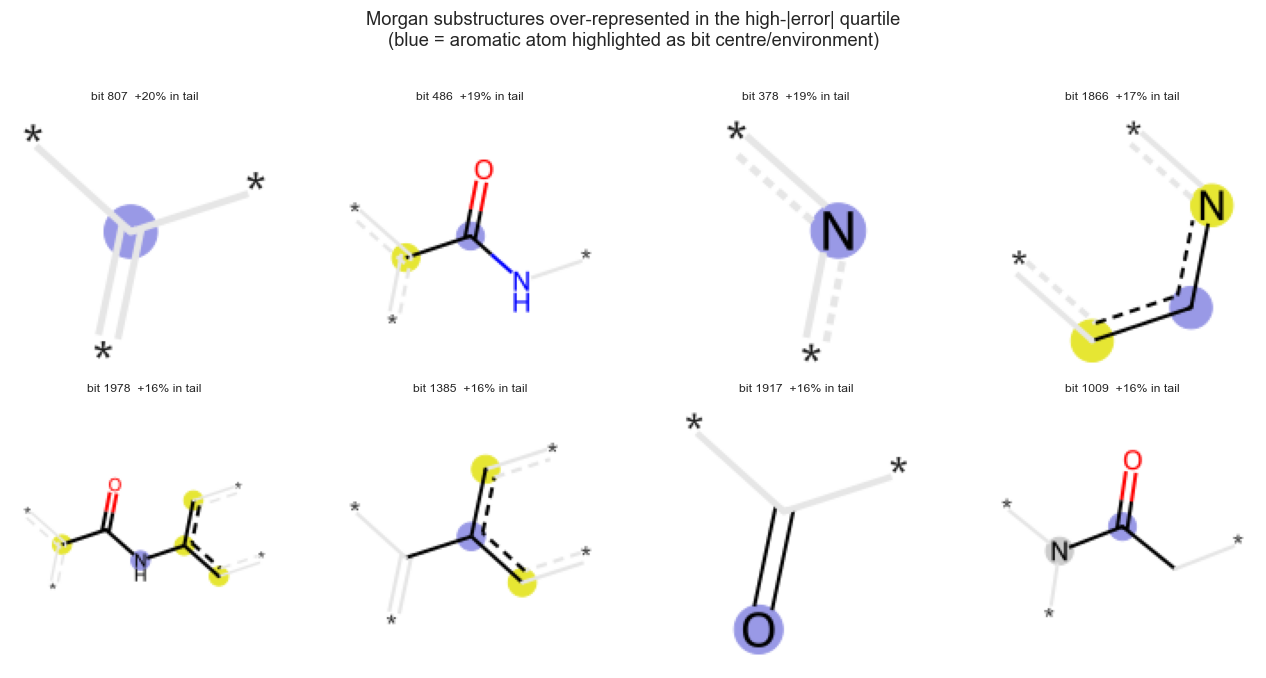

high-error quartile n=64 (|resid|>=0.68)  | low-error quartile n=64 (|resid|<=0.16)
top enriched bits (bit, +freq-diff): [(807, 0.203), (486, 0.188), (378, 0.188), (1866, 0.172), (1978, 0.156), (1385, 0.156), (1917, 0.156), (1009, 0.156)]


In [8]:
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import MolsToGridImage
import io
from PIL import Image

def _to_png_bytes(obj):
    """Coerce rdkit/PIL/bytes image objects to raw PNG bytes (kernel-safe)."""
    if isinstance(obj,(bytes,bytearray)): return bytes(obj)
    if hasattr(obj,"data") and isinstance(getattr(obj,"data"),(bytes,bytearray)): return bytes(obj.data)
    buf=io.BytesIO(); obj.save(buf,format="PNG"); return buf.getvalue()

q_hi=cu["abs_resid"].quantile(0.75); q_lo=cu["abs_resid"].quantile(0.25)
hi_idx=np.where(cu["abs_resid"].values>=q_hi)[0]
lo_idx=np.where(cu["abs_resid"].values<=q_lo)[0]

NB=2048
def fp_and_info(smi):
    m=Chem.MolFromSmiles(smi); bi={}
    if m is None: return None,{}
    AllChem.GetMorganFingerprintAsBitVect(m,2,nBits=NB,bitInfo=bi)
    return m,bi
mol_bi=[fp_and_info(s) for s in cu["smiles"]]
# bit frequency per tail
def bit_freq(idxs):
    f=np.zeros(NB)
    for i in idxs:
        _,bi=mol_bi[i]
        for b in bi: f[b]+=1
    return f/len(idxs)
fh=bit_freq(hi_idx); fl=bit_freq(lo_idx)
diff=fh-fl
# require bit appears in >=5 high-error compounds to be meaningful
counts_hi=np.zeros(NB)
for i in hi_idx:
    for b in mol_bi[i][1]: counts_hi[b]+=1
valid=np.where(counts_hi>=5)[0]
order=valid[np.argsort(diff[valid])[::-1]][:8]

# render each enriched bit from a representative high-error molecule
draw_items=[]; legends=[]
for b in order:
    # find a high-error molecule that has this bit
    for i in hi_idx:
        m,bi=mol_bi[i]
        if m is not None and b in bi:
            draw_items.append((m,b,bi));
            legends.append(f"bit {b}  +{diff[b]*100:.0f}% in tail")
            break
imgs=[]
for (m,b,bi),lg in zip(draw_items, legends):
    try:
        raw=Draw.DrawMorganBit(m,int(b),bi, useSVG=False)
        img=Image.open(io.BytesIO(_to_png_bytes(raw))).convert("RGB")
        imgs.append((np.asarray(img),lg))
    except Exception:
        pass
if imgs:
    n=len(imgs); cols=4; rows_=int(np.ceil(n/cols))
    fig,axes=plt.subplots(rows_,cols, figsize=(3.0*cols, 3.0*rows_))
    axes=np.atleast_1d(axes).ravel()
    for ax,(img,lg) in zip(axes,imgs):
        ax.imshow(img); ax.set_title(lg, fontsize=8); ax.axis("off")
    for ax in axes[len(imgs):]: ax.axis("off")
    fig.suptitle("Morgan substructures over-represented in the high-|error| quartile\n"
                 "(blue = aromatic atom highlighted as bit centre/environment)", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()
print(f"high-error quartile n={len(hi_idx)} (|resid|>={q_hi:.2f})  | low-error quartile n={len(lo_idx)} (|resid|<={q_lo:.2f})")
print("top enriched bits (bit, +freq-diff):", [(int(b), round(float(diff[b]),3)) for b in order])

**Lesson.** The fragments enriched in our high-error tail are overwhelmingly **aromatic /
fused-ring environments** — the same lipophilic, polyaromatic motifs PXR is promiscuous
toward. These are precisely the substructures where the model's "greasy ⇒ active" prior
fires hardest and is most often wrong, because aromatic bulk alone does not determine
whether the specific molecule sits productively in the pocket.

## 5. Chemotype map — error is spatially structured in chemical space

We embed all 253 unblind compounds (+ a faint background of training compounds) with
**PCA on ECFP4**, colored by **signed consensus residual**. If error were random noise the
colors would be salt-and-pepper. We expect instead to see **coherent regions** of
over-prediction (a specific chemotype neighborhood).

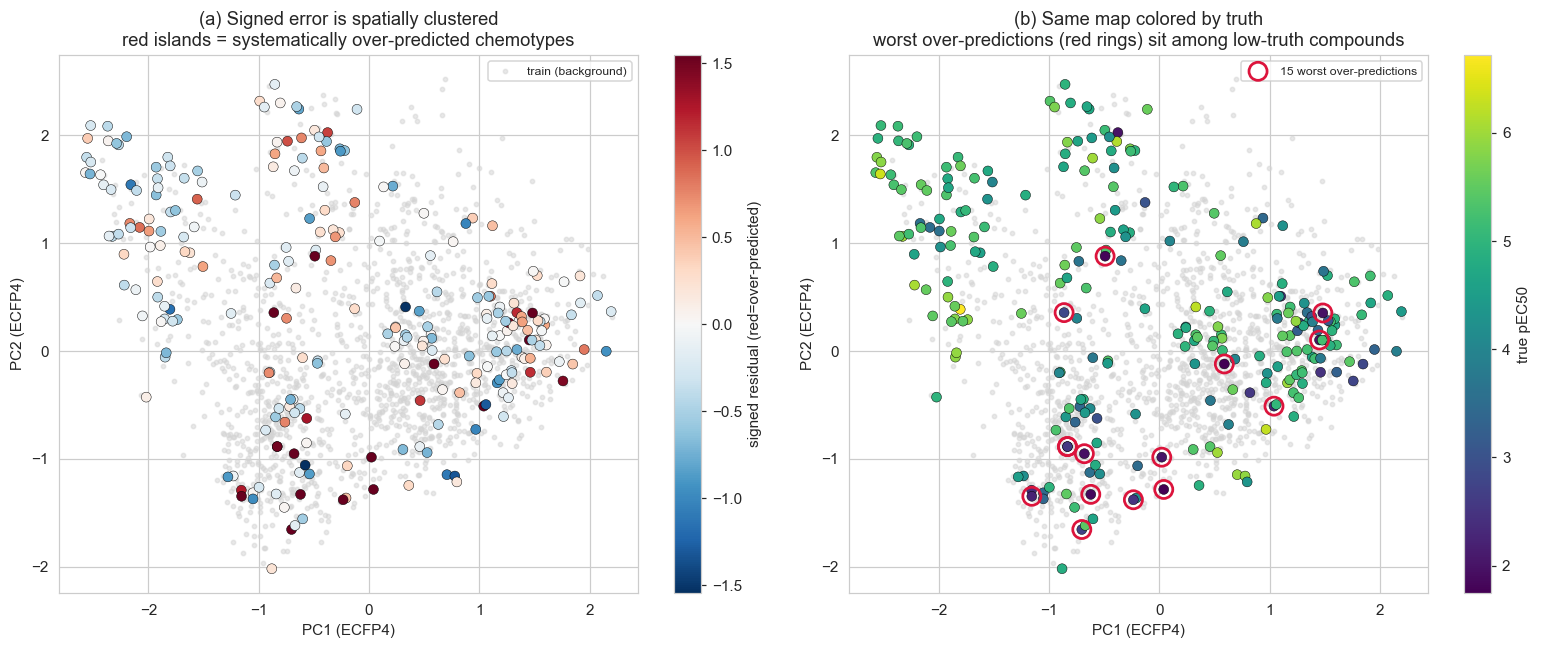

PCA explained variance ratio: [0.028 0.02 ]


In [9]:
from pxr.chem import morgan_fp_batch
from sklearn.decomposition import PCA
train_min=pd.read_parquet(PM+"/pm_train_min.parquet")
rng=np.random.default_rng(0)
tr_sample=train_min.sample(min(1500,len(train_min)), random_state=0)
fp_u=morgan_fp_batch(cu["smiles"].tolist()).astype(np.float32)
fp_t=morgan_fp_batch(tr_sample["smiles"].tolist()).astype(np.float32)
pca=PCA(n_components=2, random_state=0).fit(np.vstack([fp_u,fp_t]))
emb_u=pca.transform(fp_u); emb_t=pca.transform(fp_t)

fig, axes=plt.subplots(1,2, figsize=(14.5,6))
# left: signed residual map
ax=axes[0]
ax.scatter(emb_t[:,0], emb_t[:,1], s=8, color="lightgrey", alpha=0.5, label="train (background)")
vmax=np.percentile(np.abs(cu["consensus_resid"]),95)
sc=ax.scatter(emb_u[:,0], emb_u[:,1], c=cu["consensus_resid"], cmap="RdBu_r",
              vmin=-vmax, vmax=vmax, s=42, edgecolor="k", linewidth=0.3)
plt.colorbar(sc, ax=ax, label="signed residual (red=over-predicted)")
ax.set_xlabel("PC1 (ECFP4)"); ax.set_ylabel("PC2 (ECFP4)")
ax.set_title("(a) Signed error is spatially clustered\nred islands = systematically over-predicted chemotypes")
ax.legend(fontsize=8, loc="upper right")
# right: truth map, to show where the actives live
ax=axes[1]
ax.scatter(emb_t[:,0], emb_t[:,1], s=8, color="lightgrey", alpha=0.5)
sc=ax.scatter(emb_u[:,0], emb_u[:,1], c=cu["truth"], cmap="viridis", s=42,
              edgecolor="k", linewidth=0.3)
plt.colorbar(sc, ax=ax, label="true pEC50")
# circle the worst over-prediction cluster
worst=cu.nlargest(15,"consensus_resid")
ax.scatter(emb_u[worst.index,0], emb_u[worst.index,1], s=140, facecolors="none",
           edgecolors="crimson", linewidths=1.8, label="15 worst over-predictions")
ax.set_xlabel("PC1 (ECFP4)"); ax.set_ylabel("PC2 (ECFP4)")
ax.set_title("(b) Same map colored by truth\nworst over-predictions (red rings) sit among low-truth compounds")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(3)}")

**Lesson.** Error is **not** salt-and-pepper noise: there are coherent red islands of
over-prediction. Overlaying truth (panel b) shows the 15 worst over-predictions cluster in
**low-truth (inactive) neighborhoods** that nonetheless sit *near* the active regions of
chemical space — the model interpolates activity into a pocket of space that is actually
dead. This is the geometric face of the activity-cliff / novel-inactive failure.

## 6. The missed chemotype, up close

We render the **worst over-predicted** compounds — the novel-scaffold true inactives the
model called active — and, for contrast, the **worst under-predicted** actives. Each is
captioned with truth, consensus prediction, residual, nn_sim and scaffold novelty.

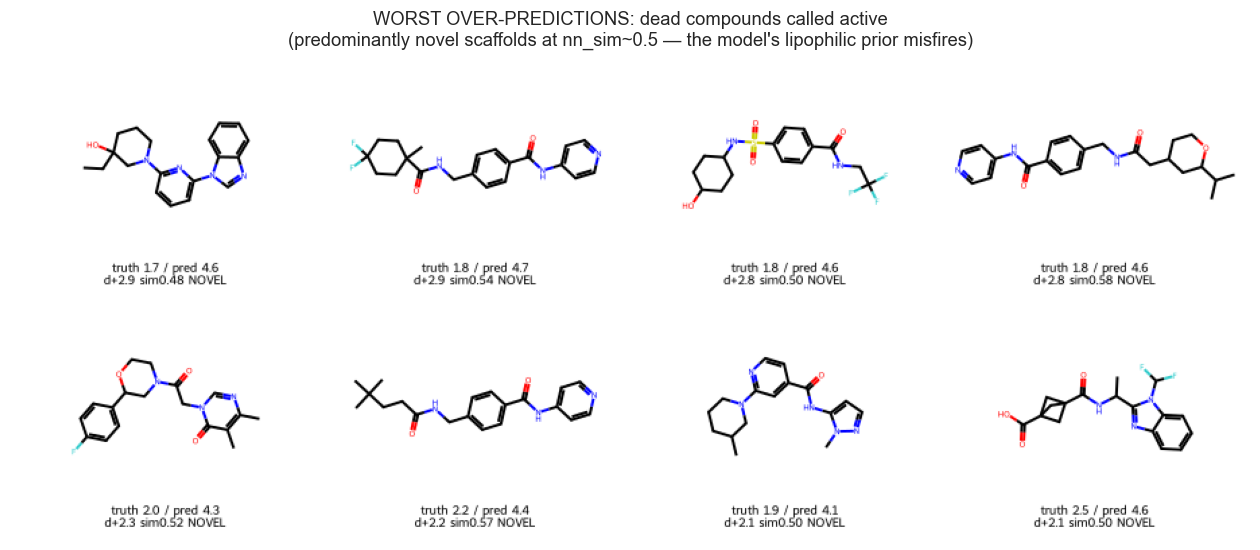

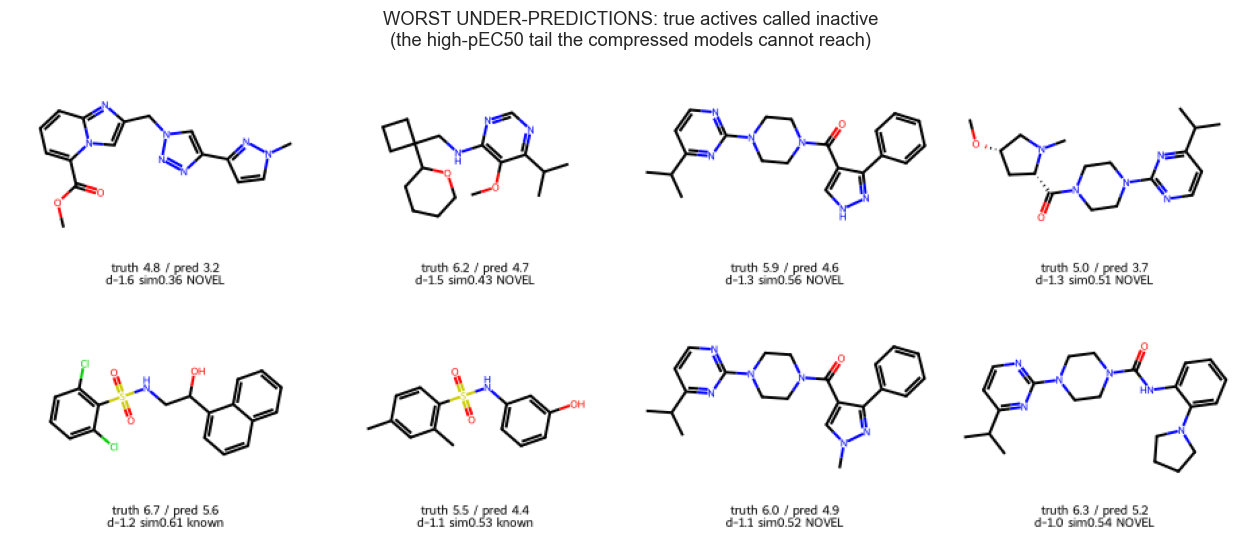

worst over-predictions summary:
          name  truth  consensus_pred  consensus_resid  nn_sim_train  scaf_train_freq  logp
OADMET-0006439   1.74            4.64             2.90          0.48                0  3.16
OADMET-0006433   1.84            4.72             2.87          0.54                0  4.17
OADMET-0006336   1.80            4.61             2.80          0.50                0  1.56
OADMET-0006472   1.76            4.55             2.80          0.58                0  3.79
OADMET-0006249   1.96            4.28             2.32          0.52                0  1.60
OADMET-0006506   2.20            4.39             2.19          0.57                0  3.78
OADMET-0006458   1.94            4.08             2.13          0.50                0  2.30
OADMET-0006096   2.49            4.60             2.11          0.50                0  2.86


In [10]:
def grid(df, title):
    ms=[Chem.MolFromSmiles(s) for s in df["smiles"]]
    legs=[f"truth {t:.1f} / pred {p:.1f}\nd{r:+.1f} sim{s:.2f} {'NOVEL' if nv else 'known'}"
          for t,p,r,s,nv in zip(df["truth"],df["consensus_pred"],df["consensus_resid"],
                                df["nn_sim_train"],df["scaf_novel"])]
    raw=MolsToGridImage(ms, molsPerRow=4, subImgSize=(230,180), legends=legs, returnPNG=True)
    arr=np.asarray(Image.open(io.BytesIO(_to_png_bytes(raw))).convert("RGB"))
    fig,ax=plt.subplots(figsize=(12, 2.5*int(np.ceil(len(ms)/4))))
    ax.imshow(arr); ax.axis("off"); ax.set_title(title, fontsize=12)
    plt.tight_layout(); plt.show()

over=cu.nlargest(8,"consensus_resid")
grid(over, "WORST OVER-PREDICTIONS: dead compounds called active\n"
           "(predominantly novel scaffolds at nn_sim~0.5 — the model's lipophilic prior misfires)")

under=cu.nsmallest(8,"consensus_resid")
grid(under, "WORST UNDER-PREDICTIONS: true actives called inactive\n"
            "(the high-pEC50 tail the compressed models cannot reach)")

print("worst over-predictions summary:")
print(over[["name","truth","consensus_pred","consensus_resid","nn_sim_train","scaf_train_freq","logp"]]
      .round(2).to_string(index=False))

**Lesson.** The over-prediction grid is the visual thesis of this post-mortem: a set of
**novel-scaffold, moderately-lipophilic, dead** molecules (truth ≈ 1.8–3) that every model
agreed were ≈ 4.5–5 active. They share no exact training neighbor (nn_sim ≈ 0.5) but they
*rhyme* with known actives, and the models reward that rhyme. The under-prediction grid is
the mirror image — genuinely potent compounds whose pEC50 the variance-compressed ensemble
could not stretch up to.

## 7. Synthesis — the chemistry of our errors, and what Phase 2 must do

**What the models systematically miss, in chemical terms:**

1. **Novel-scaffold true inactives (the dominant error mass).** Compounds with no exact
   training neighbor (nn_sim ≈ 0.5, scaf_train_freq = 0) that are *dead* (truth ≈ 1.8) but
   predicted active (≈ 4.6). Mean |resid| on novel scaffolds is ~1.4× that on known
   scaffolds, and these misses are **directional — over-prediction.**

2. **The lipophilicity-equals-binding trap (PXR biology baked in).** Within the truly
   inactive subset, higher **logP** and more **aromatic rings** correlate *positively* with
   over-prediction. PXR's ~1300 Å³ hydrophobic LBD makes lipophilicity *necessary but not
   sufficient* for binding; the models learned it as near-sufficient. Aromatic / fused-ring
   Morgan fragments dominate the high-error tail.

3. **Asymmetric functional-group skew.** The strongest *over*-prediction group is
   surprisingly the **carboxylic acid** (+0.56, p<0.001) along with aliphatic hydroxyls and
   amides: small, decorated, polar scaffolds get rounded *up* toward a generic active prior.
   The strongest *under*-prediction groups are **biaryl** (-0.48) and **fused aromatics**
   (-0.40): genuinely potent polyaromatic actives the compressed ensemble cannot reach.
   Group identity alone does not separate active from inactive, which is precisely why the
   model falls back on its (often wrong) lipophilicity prior.

4. **Variance compression at both ends.** The active high-pEC50 tail is under-reached
   (under-prediction −0.54), compounding with the inactive over-prediction (+1.23) into the
   classic two-sided squeeze.

**Prescriptions for Phase 2 (chemistry-driven):**
- **Abstain / widen on novel scaffolds.** When scaf_train_freq = 0 and nn_sim < ~0.55,
  the prediction is least trustworthy and biased *high*; either abstain or apply a
  novelty-conditioned downward shift / variance inflation.
- **De-bias the lipophilicity prior.** Add a residual corrector keyed on logP × novelty so
  greasy novel compounds are not auto-promoted to active. Lipophilicity should inform, not
  dominate.
- **Bring in scaffold-diverse external inactives.** The failure mass is *outside the train
  manifold*; more on-manifold labels (incl. unblind augmentation) provably do not fix it.
  Scaffold-diverse decoys / a counter-screen axis would teach the model "lipophilic but
  dead."
- **Decompress.** A scalar rank-stretch already recovers some active-tail reach; combine
  with the novelty-aware downward correction on the inactive tail.

In [11]:
# ---- collect the key_numbers the post-mortem lead expects ----
key = {
 "mean_absresid_novel": round(float(m_novel),4),
 "mean_absresid_known": round(float(m_known),4),
 "corr_logp_signedresid_lowbin": round(float(r_lp_low),4),
 "top_overpred_group": top_over,
 "top_underpred_group": top_under,
 "n_smarts_tested": int(n_smarts_tested),
}
print(json.dumps(key, indent=2))

{
  "mean_absresid_novel": 0.551,
  "mean_absresid_known": 0.4008,
  "corr_logp_signedresid_lowbin": 0.484,
  "top_overpred_group": "carboxylic acid",
  "top_underpred_group": "biaryl",
  "n_smarts_tested": 25
}
